# LSTM Model (Deep Learning Model)

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [19]:
y_train = pd.read_csv(r"C:\Users\anagh\OneDrive\Desktop\DUK\PA\Project1\ucihar-dataset\UCI-HAR Dataset\train\y_train.txt", header=None)
y_test = pd.read_csv(r"C:\Users\anagh\OneDrive\Desktop\DUK\PA\Project1\ucihar-dataset\UCI-HAR Dataset\test\y_test.txt", header=None)
y_train = y_train.values.ravel().astype(int) - 1
y_test = y_test.values.ravel().astype(int) - 1
print(y_train[:5])

[4 4 4 4 4]


In [20]:
def load_signal(file):
    return pd.read_csv(file, sep='\s+', header=None).values

X_train_signal = np.array([
    load_signal(r"C:\Users\anagh\OneDrive\Desktop\DUK\PA\Project1\ucihar-dataset\UCI-HAR Dataset\train\Inertial Signals\body_acc_x_train.txt"),
    load_signal(r"C:\Users\anagh\OneDrive\Desktop\DUK\PA\Project1\ucihar-dataset\UCI-HAR Dataset\train\Inertial Signals\body_acc_y_train.txt"),
    load_signal(r"C:\Users\anagh\OneDrive\Desktop\DUK\PA\Project1\ucihar-dataset\UCI-HAR Dataset\train\Inertial Signals\body_acc_z_train.txt"),
    load_signal(r"C:\Users\anagh\OneDrive\Desktop\DUK\PA\Project1\ucihar-dataset\UCI-HAR Dataset\train\Inertial Signals\body_gyro_x_train.txt"),
    load_signal(r"C:\Users\anagh\OneDrive\Desktop\DUK\PA\Project1\ucihar-dataset\UCI-HAR Dataset\train\Inertial Signals\body_gyro_y_train.txt"),
    load_signal(r"C:\Users\anagh\OneDrive\Desktop\DUK\PA\Project1\ucihar-dataset\UCI-HAR Dataset\train\Inertial Signals\body_gyro_z_train.txt")
]).transpose(1,2,0)

X_test_signal = np.array([
    load_signal(r"C:\Users\anagh\OneDrive\Desktop\DUK\PA\Project1\ucihar-dataset\UCI-HAR Dataset\test\Inertial Signals\body_acc_x_test.txt"),
    load_signal(r"C:\Users\anagh\OneDrive\Desktop\DUK\PA\Project1\ucihar-dataset\UCI-HAR Dataset\test\Inertial Signals\body_acc_y_test.txt"),
    load_signal(r"C:\Users\anagh\OneDrive\Desktop\DUK\PA\Project1\ucihar-dataset\UCI-HAR Dataset\test\Inertial Signals\body_acc_z_test.txt"),
    load_signal(r"C:\Users\anagh\OneDrive\Desktop\DUK\PA\Project1\ucihar-dataset\UCI-HAR Dataset\test\Inertial Signals\body_gyro_x_test.txt"),
    load_signal(r"C:\Users\anagh\OneDrive\Desktop\DUK\PA\Project1\ucihar-dataset\UCI-HAR Dataset\test\Inertial Signals\body_gyro_y_test.txt"),
    load_signal(r"C:\Users\anagh\OneDrive\Desktop\DUK\PA\Project1\ucihar-dataset\UCI-HAR Dataset\test\Inertial Signals\body_gyro_z_test.txt")
]).transpose(1,2,0)

print(X_train_signal.shape)

(7352, 128, 6)


# Normalize the data

In [21]:
mean = X_train_signal.mean()
std = X_train_signal.std()

X_train_signal = (X_train_signal - mean) / std
X_test_signal = (X_test_signal - mean) / std

In [22]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

model = Sequential([
    LSTM(128, return_sequences=True, input_shape=(128,6)),
    Dropout(0.3),

    LSTM(64),
    Dropout(0.3),

    Dense(64, activation='relu'),
    Dense(6, activation='softmax')
])

model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_2 (LSTM)               (None, 128, 128)          69120     
                                                                 
 dropout_2 (Dropout)         (None, 128, 128)          0         
                                                                 
 lstm_3 (LSTM)               (None, 64)                49408     
                                                                 
 dropout_3 (Dropout)         (None, 64)                0         
                                                                 
 dense_2 (Dense)             (None, 64)                4160      
                                                                 
 dense_3 (Dense)             (None, 6)                 390       
                                                                 
Total params: 123078 (480.77 KB)
Trainable params: 123

In [23]:
history = model.fit(
    X_train_signal,
    y_train,
    epochs=250,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/250
92/92 [==============================] - 37s 347ms/step - loss: 1.2445 - accuracy: 0.4248 - val_loss: 0.8882 - val_accuracy: 0.5432
Epoch 2/250
92/92 [==============================] - 28s 304ms/step - loss: 0.7388 - accuracy: 0.6033 - val_loss: 0.6840 - val_accuracy: 0.6016
Epoch 3/250
92/92 [==============================] - 28s 300ms/step - loss: 0.7253 - accuracy: 0.6157 - val_loss: 0.6561 - val_accuracy: 0.6322
Epoch 4/250
92/92 [==============================] - 31s 335ms/step - loss: 0.6574 - accuracy: 0.6297 - val_loss: 0.6493 - val_accuracy: 0.6173
Epoch 5/250
92/92 [==============================] - 30s 329ms/step - loss: 0.8254 - accuracy: 0.5997 - val_loss: 0.9133 - val_accuracy: 0.5772
Epoch 6/250
92/92 [==============================] - 31s 336ms/step - loss: 0.8871 - accuracy: 0.5678 - val_loss: 0.7085 - val_accuracy: 0.6105
Epoch 7/250
92/92 [==============================] - 31s 335ms/step - loss: 0.6824 - accuracy: 0.6254 - val_loss: 0.6458 - val_accuracy:

KeyboardInterrupt: 

In [ ]:
model.save("har_lstm_model.h5")

c:\Users\anagh\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\engine\training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [ ]:
loss, acc = model.evaluate(X_test_signal, y_test)
print("Test Accuracy:", acc)

93/93 [==============================] - 6s 59ms/step - loss: 0.4345 - accuracy: 0.8700
Test Accuracy: 0.870037317276001


In [ ]:
from sklearn.metrics import classification_report
import numpy as np

# Predict probabilities
y_pred_lstm = model.predict(X_test_signal)

# Convert to class labels
y_pred_lstm_classes = np.argmax(y_pred_lstm, axis=1)

print("LSTM Results\n")

# Print classification report
print(classification_report(y_test, y_pred_lstm_classes))

93/93 [==============================] - 8s 67ms/step
LSTM Results

              precision    recall  f1-score   support

           0       0.98      0.94      0.96       496
           1       0.99      0.97      0.98       471
           2       0.93      0.98      0.95       420
           3       0.82      0.64      0.72       491
           4       0.73      0.90      0.81       532
           5       0.82      0.80      0.81       537

    accuracy                           0.87      2947
   macro avg       0.88      0.87      0.87      2947
weighted avg       0.87      0.87      0.87      2947



In [ ]:
from sklearn.metrics import classification_report

report = classification_report(y_test, y_pred_lstm_classes)

with open("lstm_report.txt", "w") as f:
    f.write("LSTM Results\n")
    f.write(report)

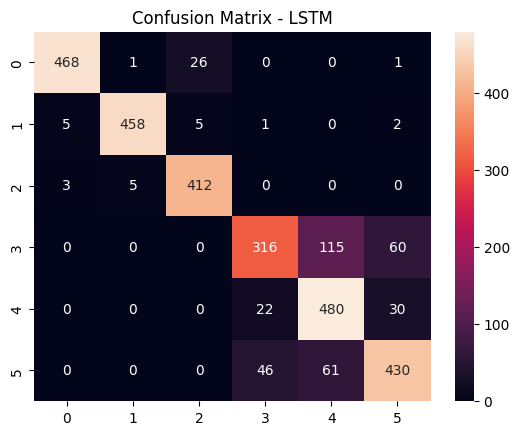

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_lstm_classes)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix - LSTM")
plt.show()

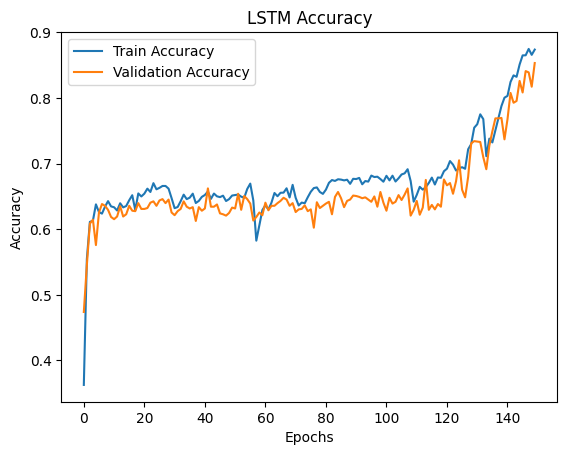

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("LSTM Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

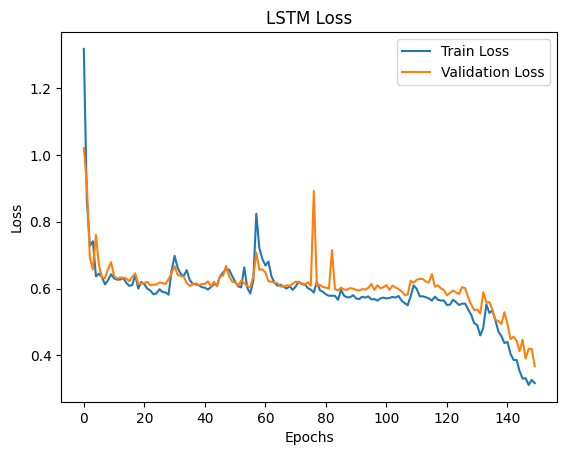

In [ ]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("LSTM Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [ ]:
import pandas as pd

history_df = pd.DataFrame(history.history)
history_df.to_csv("lstm_history.csv", index=False)

In [ ]:
print("Best Train Accuracy:", max(history.history['accuracy']))
print("Best Validation Accuracy:", max(history.history['val_accuracy']))

Best Train Accuracy: 0.8746811747550964
Best Validation Accuracy: 0.853161096572876
